# Phase/Frequency Noisy Drive qubit simulation



### Author: Daniel Gonçalves Benvenutti - UNICAMP
02 April 2025

Qutip Version: 5.1.1

In this notebook we do a study of the effects of noise in the phase of our drive signal. We input into the phase of our signal several differents types of noise as well as we treat these noises to try simulating the behavior of a controlled wave generator. We also keep in our minds the procedures of phase and frequency modulation from electrical engineering to understand the effects our disturbance has on the spectrum of our resulting signal.

The overall conclusion of these simulations is that the phase noise has more effect when it's low frequency (pink/brown noise). The low frequencies not only brings our signal out of phase during the excitation of the qubit but also off resonance when the noise signal is a slope of some sort. In the spectrum it's the lower frequencies that get shifted to near the qubit resonance when modulated where they have the largest disturbance effect. The noise in the phase also steals energy away from the main signal to other points in the spectrum increasing our Rabi period.







In [ ]:
# to use in google colab
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.1/30.1 MB 52.3 MB/s eta 0:00:00


In [ ]:
import qutip as qtp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import lsim, TransferFunction
from statsmodels.graphics.tsaplots import plot_acf

## Simulation Parameters



In [ ]:
# parameters
wq=3*2*np.pi #qubit resonance frequency [GHz.rad]
Ed=0.01*2*np.pi #driving energy [GHz.rad]

pi_pulse=np.pi/Ed #[ns]
print(f"pi pulse={pi_pulse:.2e}")

T1=2000 #relaxation time [ns]
T2=1000 #dephasing time [ns]

# (T2 must be T2<=2T1)
if T2>2*T1:
  raise Exception("T2 must be T2<=2T1")

# operators
sm=qtp.destroy(2)
sx=qtp.sigmax()
sz=qtp.sigmaz()
sy=qtp.sigmay()
n=sm.dag()*sm

# hamiltonian
def H(wq, Ed_t, tlist):# wq[rad.GHz], Ed_t[rad.GHz], tlist[ns]
  # time independant hamiltonian (normalized by wq)
  if Ed_t is None:
    return -0.5*wq*sz/wq
  # time dependant hamiltonian
  # [time independant part, [operator,time dependant operator amplitude]]
  # [qubit, [drive]]
  return qtp.QobjEvo([-0.5*wq*sz/wq,[sx/wq,Ed_t]],tlist=tlist*wq)

# colapse operators normalized by wq
def c_ops(T1, T2): #T1[ns], T2[ns]
  if T2 is None:
    return [np.sqrt(1/T1/wq)*sm]
  gamma_phi=1/T2-1/2/T1 #pure dephasing constant
  return [np.sqrt(1/T1/wq)*sm,np.sqrt(gamma_phi/2/wq)*sz]
  #return [np.sqrt(1/T1)*sm,np.sqrt(2*gamma_phi)*n] #same thing for dephasing but in different terms



pi pulse=5.00e+01


In [ ]:
def plot_tomography(res):
  fig, axes = plt.subplots(3, 1, figsize=(8, 10))  # Adjust figure size as needed

  # Plot sx
  axes[0].plot(t, res.expect[0])
  axes[0].set_xlabel('Time (ns)')
  axes[0].set_ylabel('<σx>')
  axes[0].set_title('Tomography of the noisy oscillation \n Expectation Value of $\sigma_x$')


  # Plot sy
  axes[1].plot(t, res.expect[1])
  axes[1].set_xlabel('Time (ns)')
  axes[1].set_ylabel('<σy>')
  axes[1].set_title('Expectation Value of $\sigma_y$')

  # Plot sz
  axes[2].plot(t, res.expect[2])
  axes[2].set_xlabel('Time (ns)')
  axes[2].set_ylabel('<σz>')
  axes[2].set_title('Expectation Value of $\sigma_z$')


  plt.tight_layout()  # Adjust spacing between subplots
  plt.show()

## Noise generator functions from [stackoverflow](https://stackoverflow.com/questions/67085963/generate-colors-of-noise-in-python).

In [ ]:
def noise_psd(N, psd = lambda f: 1):
        X_white = np.fft.rfft(np.random.randn(N));
        S = psd(np.fft.rfftfreq(N))
        # Normalize S
        S = S / np.sqrt(np.mean(S**2))
        X_shaped = X_white * S;
        return np.fft.irfft(X_shaped);

def PSDGenerator(f):
    return lambda N: noise_psd(N, f)

@PSDGenerator
def white_noise(f):
    return 1;

@PSDGenerator
def blue_noise(f):
    return np.sqrt(f);

@PSDGenerator
def violet_noise(f):
    return f;

@PSDGenerator
def brownian_noise(f):
    return 1/np.where(f == 0, float('inf'), f)

@PSDGenerator
def pink_noise(f):
    return 1/np.where(f == 0, float('inf'), np.sqrt(f))

## Pink phase noise
Phase noise in a wave generator is typically of this kind. So we first try to generate some using the convenient functions provided by an user in a stackoverflow post that generate white noise and reshapse it's spectrum in the frequency domain for each kind of noise.

If we are lucky with our randomly generated noise we can observe that the pink noise will sometimes destroy the Rabi oscillation dynamics of the system and then allow it to go normal again.



We can understand why this happens by studying a bit of phase and frequency modulation in our wave:

$$ y(t) = A \sin (\omega t+\phi)$$


If we frequency modulate a white noise we put the phase term of our signal as an integral of the white noise. That's the procedure for frequency modulation.

$$ y(t) = A \sin (\omega t+\phi(t))$$

$$\phi(t) = \int_{-\infty}^t \textrm{White  noise}(\tau) d\tau$$

 If we modulated a square wave this way for example, by virtue of it being a time dependant integral with $t$ the inside of the sine wave would look like

$$\phi(t) = \int_{-\infty}^t \textrm{Square wave}(\tau) d\tau = \textrm{Triangle Wave}(t)$$

Where the amplitude of the square wave $\pm A$ is the slope of the triangle $\pm At$. In the upward slope cycle of the triangular wave our resulting signal would look like:

 $$ y(t) = A \sin (\omega t+At)$$

 and the downward:


 $$ y(t) = A \sin (\omega t-At)$$

 So the instantaneous frequency of a square wave modulated into a sine wave carrier is $\omega\pm A$ for this example.

What this tells us is that by integrating our signal is that we can modulate it into our frequency. So to model a white noise in the frequency we actually have to put brown noise into the phase. Brown noise is the cumulative integral in time of white noise, it's also called a random walk or brownian noise. The spectrum of brownian noise is a 1/f curve as you would expect to be the an integral in time domain when in the frequency domain with the fourier transform.

Now back to pink noise, thinking in terms of the spectrum. Since the spectrum of the pink noise is inhomogenous and it gets modulated if we add it to the phase, the majority of our noise is now near the qubit resonance and our qubit is not as robust to this kind of noise.

 In the time domain we can think pink noise is actually a kind of an intermediary between brown and white noise. It's spectrum is given by $1/\sqrt{f}$ and we generate it like said before by manipulating the spectrum of white noise to conform to this curve $1/\sqrt{f}$. The brown part of the pink noise will modulate the frequency when there's a slope in the time domain and cause the most disturbance in the dynamics because it will make the drive lose resonance with the qubit. The white noise part will have the same effect we have seen above. Seeing it in this way you can see in why in the spectrum most of the noise is around the resonance frequency due to the brown part of the noise while the rest of the noise is distributed around the rest of the spectrum.

The brown noise part of the pink noise or low frequency noise will also random walk away from the zero phase spot and not always come back. This doesn't represent well the behaviour of a wave generator that has control loops to ensure the output frequency/phase is the right one. It means for our quantum system that the main drive lost it's phase coherence and it may destroy our Rabi oscillation like it was said before we can sometimes observe in this part.


So we will try to model our phase/frequency noise differently in the next section.

In [ ]:
#signal parameters
Det=0 # [GHz]
wd=wq+Det*2*np.pi # [rad.GHz]
tlist=np.linspace(0,500,int(500*3000/wq)+1) # ns
pure_drive=lambda t,phi: Ed*(np.sin((wd)*t+phi))
noise=50*np.pi/180*pink_noise(len(tlist))
drive_data=pure_drive(tlist,noise)#+0.1*white_noise(len(tlist))*Ed

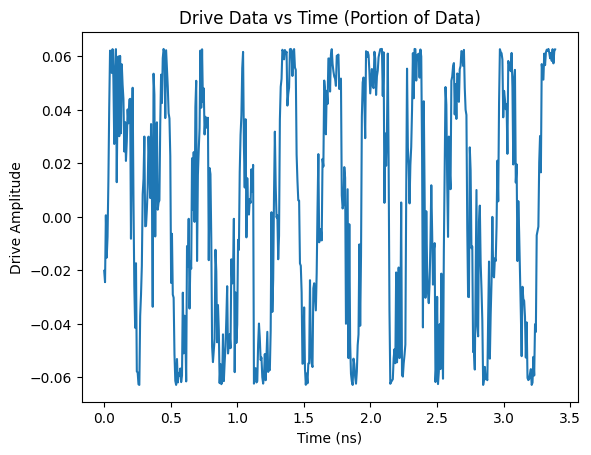

In [ ]:

# Define the start and end indices for the portion you want to plot
start_index = 0
end_index = int(64/wq/500*len(tlist))  # Adjust as needed

# Create the plot for a specific range of 'tlist' and 'drive_data'
plt.plot(tlist[start_index:end_index], drive_data[start_index:end_index])
#plt.plot(tlist[start_index:end_index],0.05*np.random.normal(0,1, tlist.shape)[start_index:end_index])
plt.xlabel('Time (ns)')
plt.ylabel('Drive Amplitude')
plt.title('Drive Data vs Time (Portion of Data)')
plt.show()


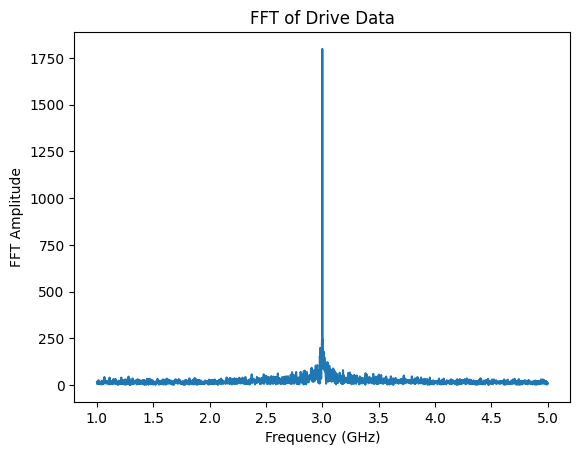

In [ ]:
# prompt: plot the fft of drive_data with a proper freq axis

# Calculate the FFT
drive_fft = np.fft.fft(drive_data)

# Calculate the corresponding frequencies
freq = np.fft.fftfreq(len(tlist), d=tlist[1] - tlist[0])
middle=len(freq)//2
zoom=np.where((freq[:middle]>=1) & (freq[:middle]<=5))[0]
# Plot the FFT with proper frequency axis
plt.plot(freq[zoom], np.abs(drive_fft)[zoom])
plt.xlabel('Frequency (GHz)')
plt.ylabel('FFT Amplitude')
plt.title('FFT of Drive Data')
plt.show()


In [ ]:
# initial state
psi0=qtp.basis(2,0)
t=np.linspace(0,500,1000) #ns
res=qtp.mesolve(H(wq,drive_data,tlist),psi0,t*wq,c_ops(T1, T2),e_ops=[sx, sy, sz],options=dict(nsteps=5000))

# rabi osc pi pulse
i=np.argmin(res.expect[2])
print("pi pulse:", t[i])


pi pulse: 33.033033033033036


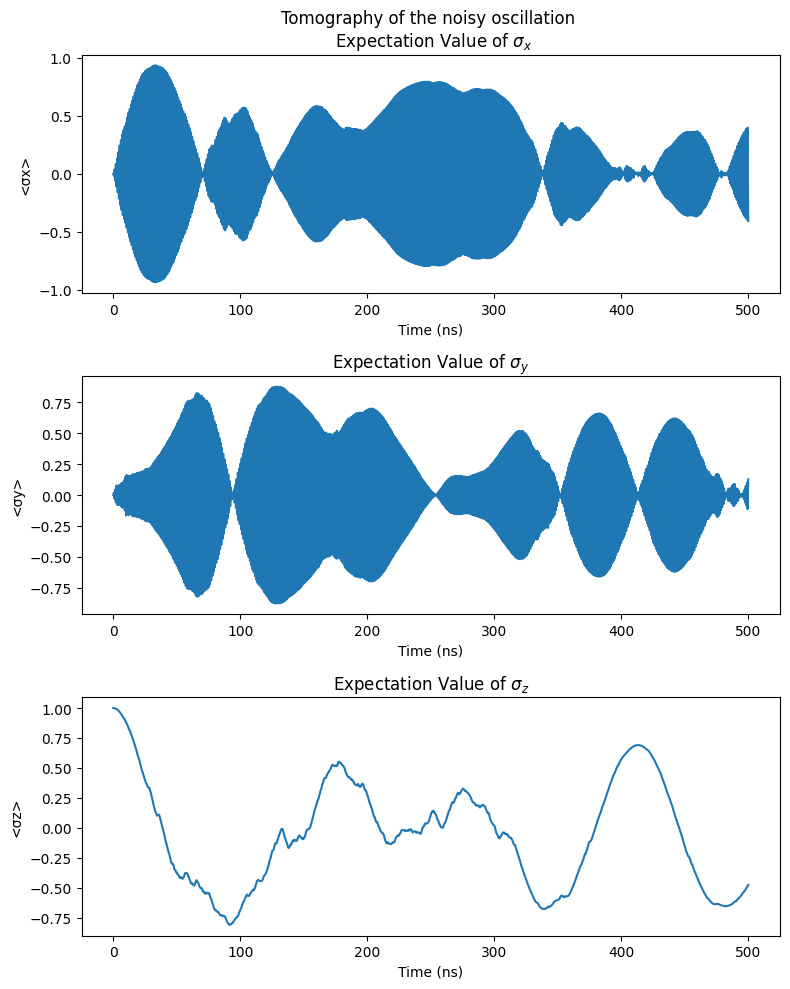

In [ ]:
plot_tomography(res)

## PID damped brownian phase noise
Here we try to make a simulation of what a real wave generator would do. At each step we add cummulatively some white noise to the frequency, this would make our system have brownian noise in the frequency, that we will integrate again into a theta resulting in a $H(s)=\frac{K}{s^2}$ transfer function. Then we read the phase of the system and insert the error into a PID controller adding the control signal into the frequency.

If we tune the PID parameters right we get a stable system with a browian sort of noise that is controlled to go back to 0 like a real system. The problem is that unless you are highly experienced with control engineering and PIDs adjusting the parameters is not very intuitive, it's very hard to get a signal satisying your expectations, it also can get unstable and diverge and there are too many parameters without a clear intuition of how each one will affect the system.

By seeing the resulting Rabi oscillation I wasn't satisfied with the kind of noise I got. It doesn't look like the real world curve we see in experiments. The noise is not uniform.



In [ ]:
def PID_brownian_noise(tlist):
  #For a wave generator plant with control on the phase
  N=len(tlist)
  dt=tlist[1]-tlist[0]

  #PID constants
  Kp=0.05
  Ki=1e-4
  Kd=0.2

  K=1 #plant constant

  mag=0.01 #noise magnitude

  theta=np.empty(N)
  f=np.empty(N)

  theta[0]=0
  f[0]=0
  integral=0
  previous_error=0

  for i in range(1,N):
    DW=mag*np.random.normal(0,np.sqrt(dt)) #brownian noise step
    f[i] = f[i-1] + DW #add noise in the frequency

    #proportional
    error = 0-theta[i-1]  # target is 0

    #integral
    integral += error * dt
    integral_limit=0.1 #for windup
    integral = np.clip(integral, -integral_limit, integral_limit) #antiwindup

    #derivative
    derivative = (error - previous_error) / dt

    correction = Kp * error + Ki * integral + Kd * derivative #PID correction


    # Simulate a system: we apply correction to counteract the noise and a brownian step
    f[i]+= K * correction *dt  #add correction from PID to freq
    theta[i] = theta[i-1] +2*np.pi* f[i] * dt #calculate new phase used by the PID

    previous_error= error
  return theta


In [ ]:
#signal parameters
Det=0 # [GHz]
wd=wq+Det*2*np.pi # [rad.GHz]
tlist=np.linspace(0,500,int(500*3000/wq)+1) # ns
pure_drive=lambda t,phi: Ed*(np.sin((wd)*t+phi))
noise=PID_brownian_noise(tlist)


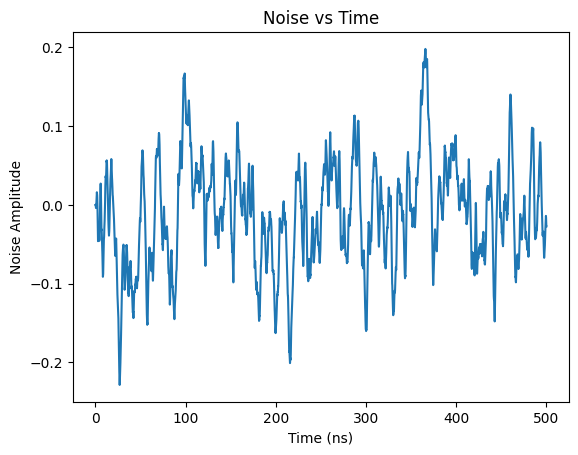

In [ ]:
# prompt: plot the noise

# Assuming 'noise' is already defined from the previous code
plt.plot(tlist, noise)
plt.xlabel('Time (ns)')
plt.ylabel('Noise Amplitude')
plt.title('Noise vs Time')
plt.show()


Let's just generate signal with exagerated noise to be able to visualize it's effect more clearly.

In [ ]:
drive_data=pure_drive(tlist,80*noise)#+0.1*white_noise(len(tlist))*Ed

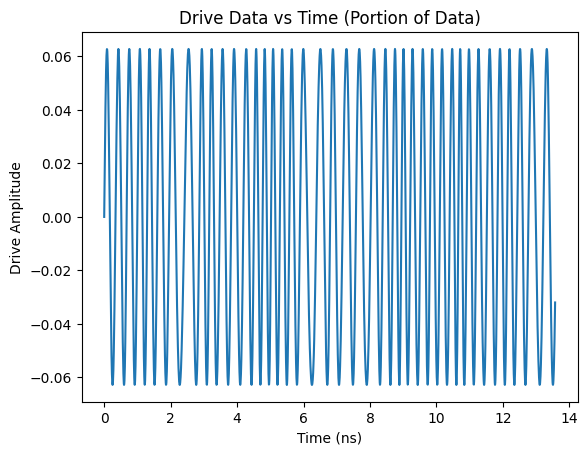

In [ ]:

# Define the start and end indices for the portion you want to plot
start_index = 0
end_index = int(256/wq/500*len(tlist))  # Adjust as needed

# Create the plot for a specific range of 'tlist' and 'drive_data'
plt.plot(tlist[start_index:end_index], drive_data[start_index:end_index])
#plt.plot(tlist[start_index:end_index],0.05*np.random.normal(0,1, tlist.shape)[start_index:end_index])
plt.xlabel('Time (ns)')
plt.ylabel('Drive Amplitude')
plt.title('Drive Data vs Time (Portion of Data)')
plt.show()


Now we use some much less aggressive noise

In [ ]:
drive_data=pure_drive(tlist,8*noise)#+0.1*white_noise(len(tlist))*Ed

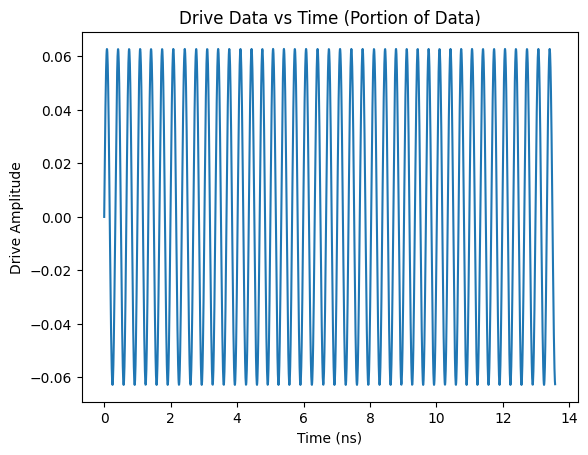

In [ ]:
# Define the start and end indices for the portion you want to plot
start_index = 0
end_index = int(256/wq/500*len(tlist))  # Adjust as needed

# Create the plot for a specific range of 'tlist' and 'drive_data'
plt.plot(tlist[start_index:end_index], drive_data[start_index:end_index])
#plt.plot(tlist[start_index:end_index],0.05*np.random.normal(0,1, tlist.shape)[start_index:end_index])
plt.xlabel('Time (ns)')
plt.ylabel('Drive Amplitude')
plt.title('Drive Data vs Time (Portion of Data)')
plt.show()

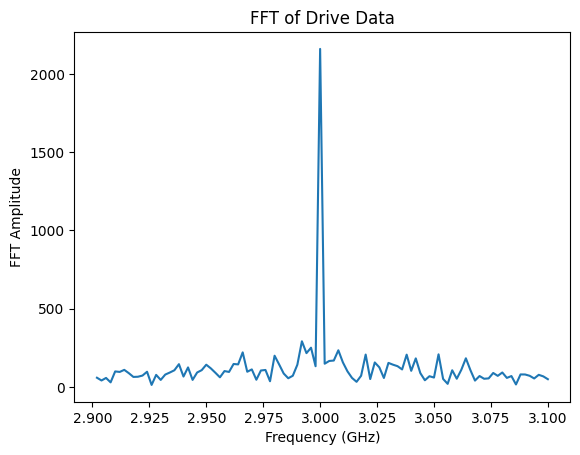

In [ ]:
# prompt: plot the fft of drive_data with a proper freq axis

# Calculate the FFT
drive_fft = np.fft.fft(drive_data)

# Calculate the corresponding frequencies
freq = np.fft.fftfreq(len(tlist), d=tlist[1] - tlist[0])
middle=len(freq)//2
zoom=np.where((freq[:middle]>=2.9) & (freq[:middle]<=3.1))[0]
# Plot the FFT with proper frequency axis
plt.plot(freq[zoom], np.abs(drive_fft)[zoom])
plt.xlabel('Frequency (GHz)')
plt.ylabel('FFT Amplitude')
plt.title('FFT of Drive Data')
plt.show()


In [ ]:
# initial state
psi0=qtp.basis(2,0)
t=np.linspace(0,500,1000) #ns
res=qtp.mesolve(H(wq,drive_data,tlist),psi0,t*wq,c_ops(T1, T2),e_ops=[sx, sy, sz],options=dict(nsteps=5000))

# rabi osc pi pulse
i=np.argmin(res.expect[2])
print("pi pulse:", t[i])


pi pulse: 56.556556556556565


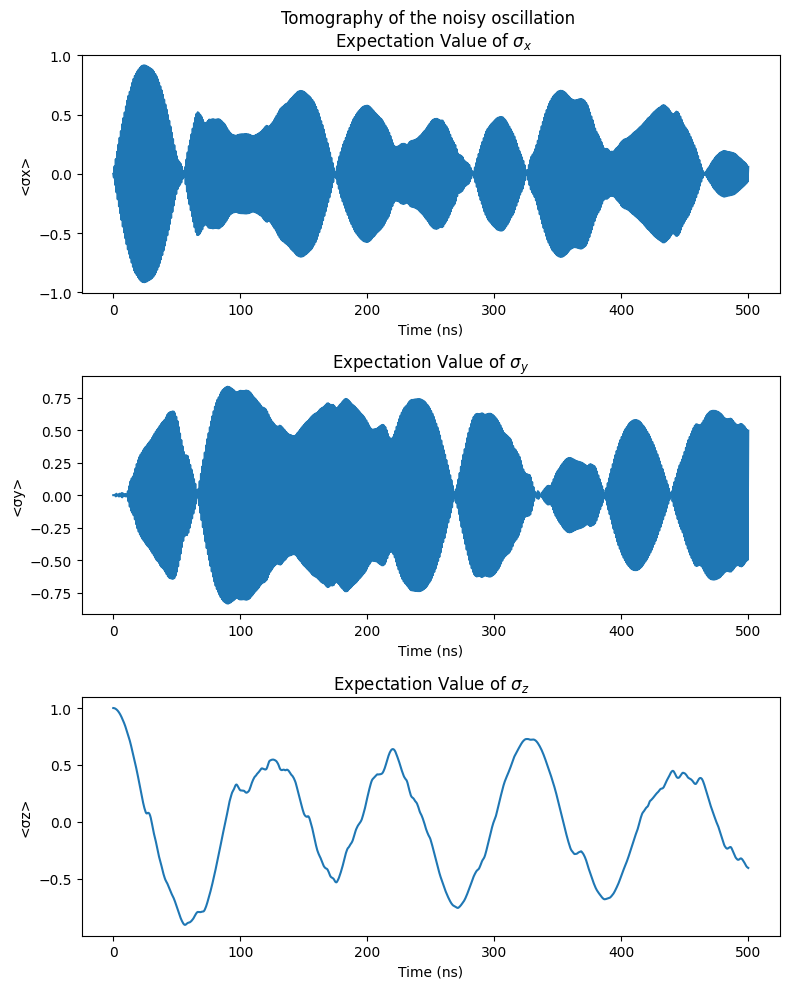

In [ ]:
plot_tomography(res)

## Second order damped harmonic oscillator with noisy applied force phase noise
A brownian noise could be described as an white noise input $F(t)=\textrm{White Noise}(t)$ going through a linear system ($Y(s)=H(s)F(s)$) with transfer function $H(s)=\frac{1}{s}$ which will give us a $\frac{1}{f}$ spectrum and be equivalent to a convolution with the constant function or a step, which is a simple cumulative integral $y(t)=\int^t_0 x(\tau)\cdot 1 d\tau$, the proper method of generating brown noise.

What I do to generate my controlled loop noise source now is using as transfer function the mass-spring damped harmonic oscillator $H(s)=\frac{1}{ms^2+bs+k}$ on this noise $F(t)$ that can be of any kind which would be a noise force applied on this mass-spring system. In terms of differential equations we write:

$$
m\ddot{y}(t)+b\dot{y}(t)+ky(t)=F(t)
$$

Where $F(t)$ is the noise and  the solution $y(t)$ is our controlled loop "brown" noise.

A correctly tuned and elaborate controlled loop to estabilize our wave source can usually already be approximated to a second order system like the damped spring-mass and the parameters of this system are very intuitive to adjust. $m$ is the inertia, $b$ the damping and $k$ the springs force in relation to the distance. Another advantage of this method is that since a control loop has the output connected to the input, noise added to the output can be treated as an input. This allows us to use any kind of noise and bind it with a control loop.

The noise we get in our rabi oscillation for this approach is more uniform and looks more realistic as well as the code gets much simpler by using existing linear system libraries to manipulate our initial noise. We can more easily make the dynamics of our system faster by for example reducing mass or increasing $k$, or we can make it slower. Finally our system is stable and won't diverge if we mistune the parameters since it's necessarily BIBO (bounded input-bounded output) stable if we have positive values for the parameters unlike our PID model.

The problem with this model is that the resulting control transfer function is just a second order low pass filter that won't filter out constant errors in the system. In the next section we will use a band pass transfer function of the closed loop as the best approximation because a high quality wave generator would certainly have a kind of integrator on the control loop because the low frequency noise is the one most disruptive to our excitation drive because because it makes it go off phase/frequency. You can notice it doing it when the Rabi oscillation goes out of the typical pattern.

### White noise

In [ ]:
def noisy_damped_HO(tlist, x_t, k=1,b=1,m=1):
  #Y(s)=H(s)X(s)
  #system H(s) for a damped mass spring
  tf=TransferFunction([1/m],[1, b/m, k/m])
  #y(t)
  _, y_t, _ = lsim(tf, U=x_t, T=tlist)
  return y_t


In [ ]:
#signal parameters
Det=0 # [GHz]
wd=wq+Det*2*np.pi # [rad.GHz]
tlist=np.linspace(0,500,int(500*3000/wq)+1) # ns
pure_drive=lambda t,phi: Ed*(np.sin((wd)*t+phi))
noise=noisy_damped_HO(tlist, white_noise(len(tlist)))


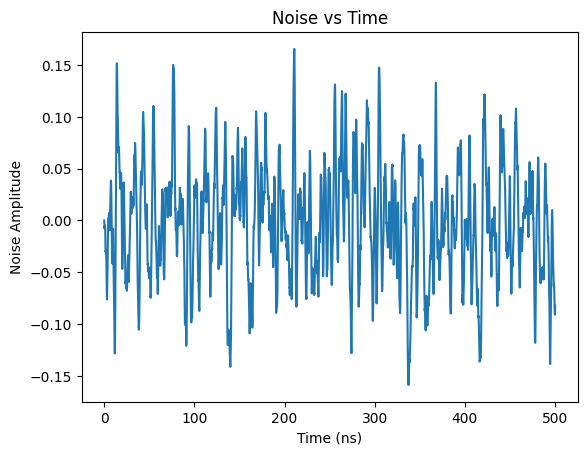

In [ ]:
# prompt: plot the noise

# Assuming 'noise' is already defined from the previous code
plt.plot(tlist, noise)
plt.xlabel('Time (ns)')
plt.ylabel('Noise Amplitude')
plt.title('Noise vs Time')
plt.show()


Let's just generate signal with exagerated noise to be able to visualize it's effect more clearly.

In [ ]:
drive_data=pure_drive(tlist,80*noise)#+0.1*white_noise(len(tlist))*Ed

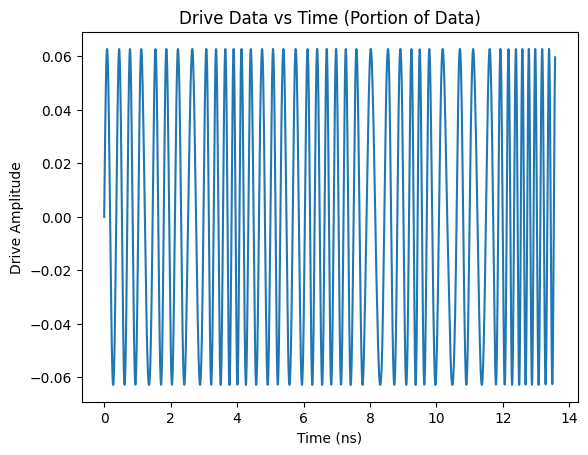

In [ ]:

# Define the start and end indices for the portion you want to plot
start_index = 0
end_index = int(256/wq/500*len(tlist))  # Adjust as needed

# Create the plot for a specific range of 'tlist' and 'drive_data'
plt.plot(tlist[start_index:end_index], drive_data[start_index:end_index])
#plt.plot(tlist[start_index:end_index],0.05*np.random.normal(0,1, tlist.shape)[start_index:end_index])
plt.xlabel('Time (ns)')
plt.ylabel('Drive Amplitude')
plt.title('Drive Data vs Time (Portion of Data)')
plt.show()


Now we use some much less aggressive noise

In [ ]:
drive_data=pure_drive(tlist,5*np.pi*noise)#+0.1*white_noise(len(tlist))*Ed

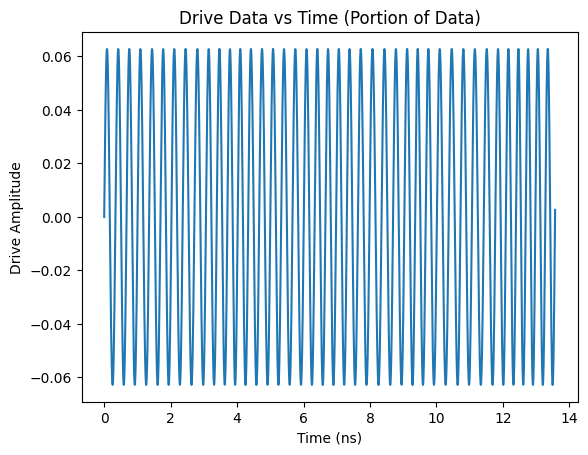

In [ ]:
# Define the start and end indices for the portion you want to plot
start_index = 0
end_index = int(256/wq/500*len(tlist))  # Adjust as needed

# Create the plot for a specific range of 'tlist' and 'drive_data'
plt.plot(tlist[start_index:end_index], drive_data[start_index:end_index])
#plt.plot(tlist[start_index:end_index],0.05*np.random.normal(0,1, tlist.shape)[start_index:end_index])
plt.xlabel('Time (ns)')
plt.ylabel('Drive Amplitude')
plt.title('Drive Data vs Time (Portion of Data)')
plt.show()

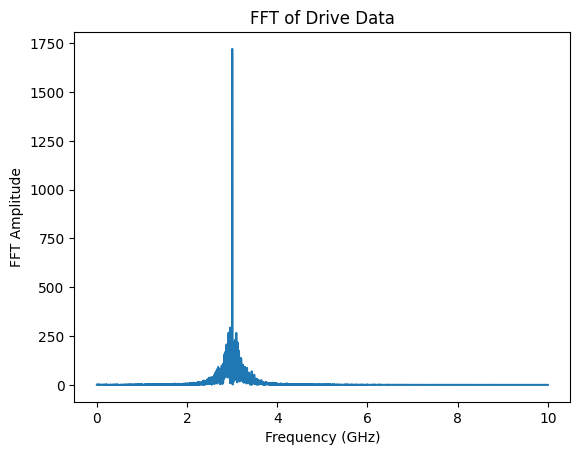

In [ ]:
# prompt: plot the fft of drive_data with a proper freq axis

# Calculate the FFT
drive_fft = np.fft.fft(drive_data)

# Calculate the corresponding frequencies
freq = np.fft.fftfreq(len(tlist), d=tlist[1] - tlist[0])
middle=len(freq)//2
zoom=np.where((freq[:middle]>=0)&(freq[:middle]<=10))[0]
# Plot the FFT with proper frequency axis
plt.plot(freq[zoom], np.abs(drive_fft)[zoom])
plt.xlabel('Frequency (GHz)')
plt.ylabel('FFT Amplitude')
plt.title('FFT of Drive Data')
plt.show()


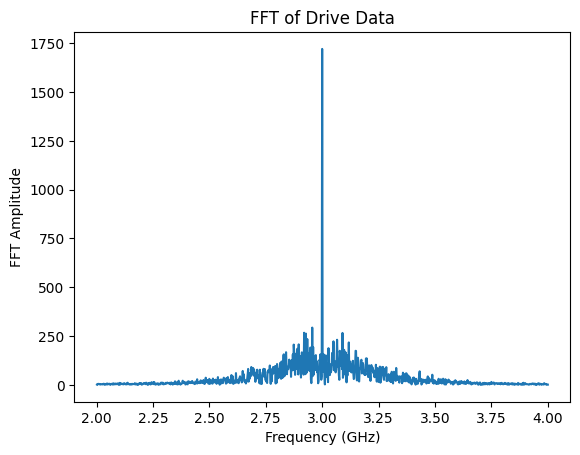

In [ ]:
zoom=np.where((freq[:middle]>=2)&(freq[:middle]<=4))[0]
# Plot the FFT with proper frequency axis
plt.plot(freq[zoom], np.abs(drive_fft)[zoom])
plt.xlabel('Frequency (GHz)')
plt.ylabel('FFT Amplitude')
plt.title('FFT of Drive Data')
plt.show()

In [ ]:
# initial state
psi0=qtp.basis(2,0)
t=np.linspace(0,500,1000) #ns
res=qtp.mesolve(H(wq,drive_data,tlist),psi0,t*wq,c_ops(T1, T2),e_ops=[sx, sy, sz],options=dict(nsteps=5000))

# rabi osc pi pulse
i=np.argmin(res.expect[2])
print("pi pulse:", t[i])


pi pulse: 70.57057057057058


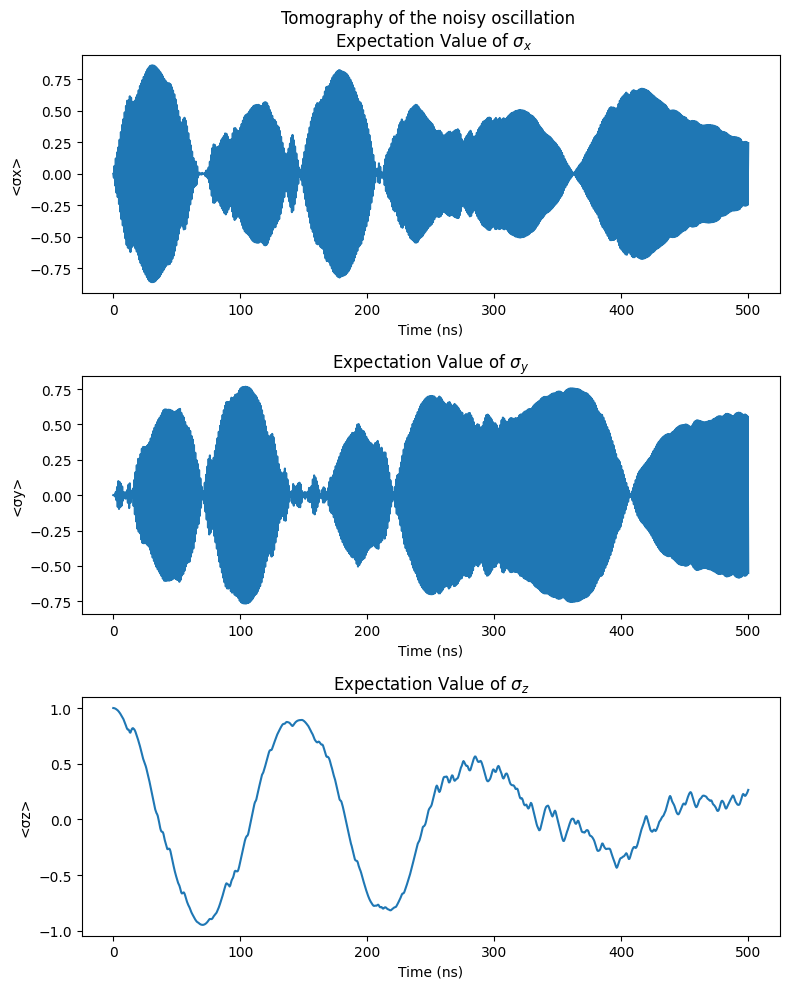

In [ ]:
plot_tomography(res)

### Pink noise

In [ ]:
#signal parameters
Det=0 # [GHz]
wd=wq+Det*2*np.pi # [rad.GHz]
tlist=np.linspace(0,500,int(500*3000/wq)+1) # ns
pure_drive=lambda t,phi: Ed*(np.sin((wd)*t+phi))
noise=noisy_damped_HO(tlist, 1*pink_noise(len(tlist)),m=15, k=20,b=4)


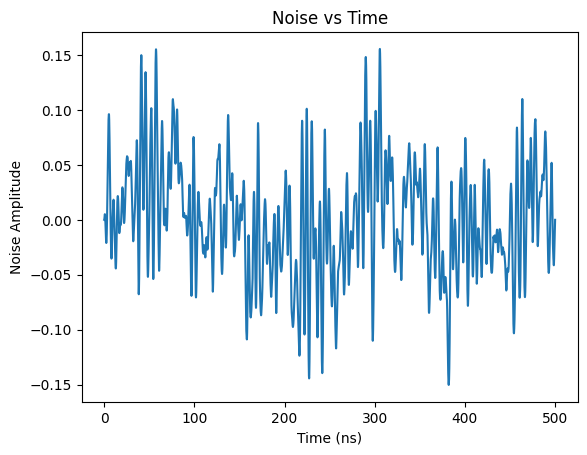

0.05091902649074534


In [ ]:
# prompt: plot the noise

# Assuming 'noise' is already defined from the previous code
plt.plot(tlist, noise)
plt.xlabel('Time (ns)')
plt.ylabel('Noise Amplitude')
plt.title('Noise vs Time')
plt.show()
print(np.std(noise))


In [ ]:
drive_data=pure_drive(tlist,4*np.pi*noise)#+0.1*white_noise(len(tlist))*Ed

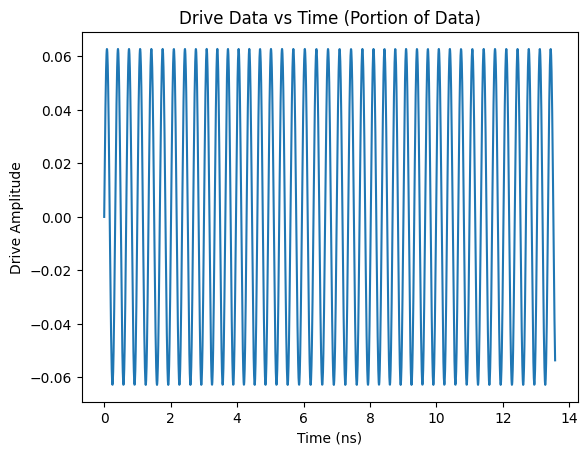

In [ ]:
# Define the start and end indices for the portion you want to plot
start_index = 0
end_index = int(256/wq/500*len(tlist))  # Adjust as needed

# Create the plot for a specific range of 'tlist' and 'drive_data'
plt.plot(tlist[start_index:end_index], drive_data[start_index:end_index])
#plt.plot(tlist[start_index:end_index],0.05*np.random.normal(0,1, tlist.shape)[start_index:end_index])
plt.xlabel('Time (ns)')
plt.ylabel('Drive Amplitude')
plt.title('Drive Data vs Time (Portion of Data)')
plt.show()

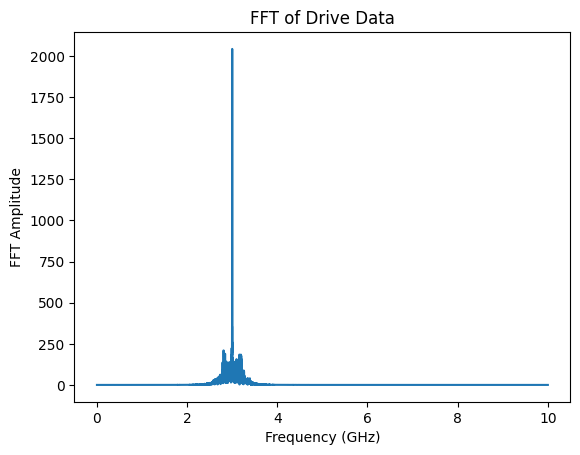

In [ ]:
# prompt: plot the fft of drive_data with a proper freq axis

# Calculate the FFT
drive_fft = np.fft.fft(drive_data)

# Calculate the corresponding frequencies
freq = np.fft.fftfreq(len(tlist), d=tlist[1] - tlist[0])
middle=len(freq)//2
zoom=np.where((freq[:middle]>=0) & (freq[:middle]<=10))[0]
# Plot the FFT with proper frequency axis
plt.plot(freq[zoom], np.abs(drive_fft)[zoom])
plt.xlabel('Frequency (GHz)')
plt.ylabel('FFT Amplitude')
plt.title('FFT of Drive Data')
plt.show()


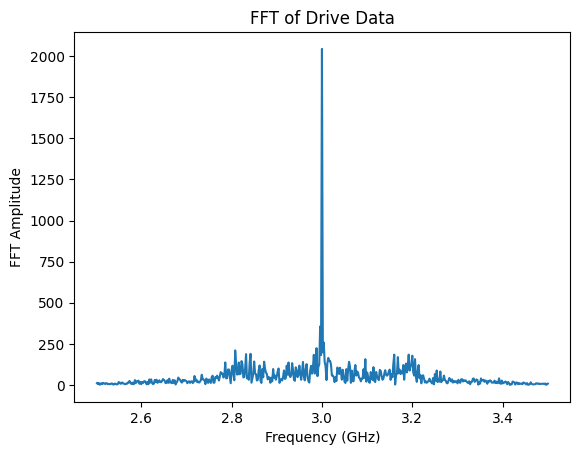

In [ ]:
zoom=np.where((freq[:middle]>=2.5) & (freq[:middle]<=3.5))[0]
# Plot the FFT with proper frequency axis
plt.plot(freq[zoom], np.abs(drive_fft)[zoom])
plt.xlabel('Frequency (GHz)')
plt.ylabel('FFT Amplitude')
plt.title('FFT of Drive Data')
plt.show()

In [ ]:
# initial state
psi0=qtp.basis(2,0)
t=np.linspace(0,500,1000) #ns
res=qtp.mesolve(H(wq,drive_data,tlist),psi0,t*wq,c_ops(T1, T2),e_ops=[sx, sy, sz],options=dict(nsteps=5000))

# rabi osc pi pulse
i=np.argmin(res.expect[2])
print("pi pulse:", t[i])


pi pulse: 56.056056056056065


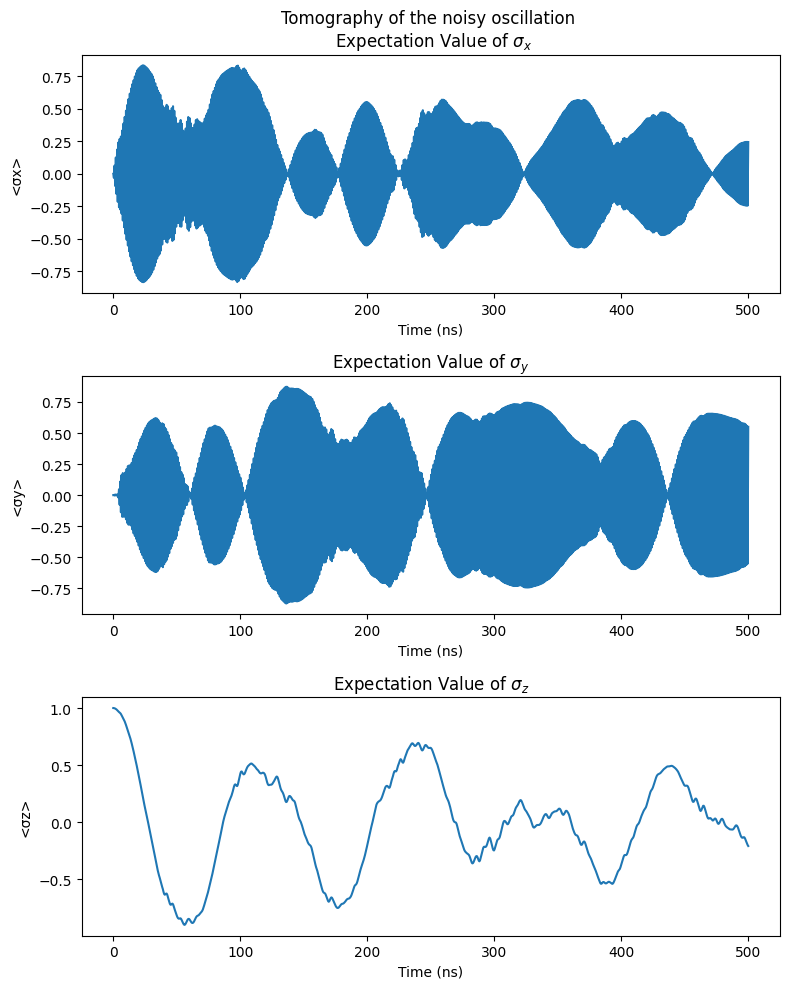

In [ ]:
plot_tomography(res)

# Band pass filter phase noise
Here instead of a low pass filter represented previously by a mass spring damped system we use a band pass filter that will also remove the low frequency noise. Which is the case of phase/frequency noise seems to be more important because it shifts the signal out of phase and resonance. Our band pass filter has a transfer function:
$$H(s)=G\frac{\frac{\omega_0}{Q}s}{s^2+\frac{\omega_0}{Q}s+\omega_0^2}$$
Where $\omega_0$ is the center frequency and $Q$ the reciprocal of the bandwidth. It is a bandpass filter because both $s\rightarrow 0$ and $s\rightarrow \infty$ go to zero on our transfer function.

Thinking about our physical system, a control loop wave generator the closed loop transfer function of the noise on the output is given by:
$$H(s)=\frac{1}{1+C(s)G(s)}$$
Where $C(s)$ is the controller transfer function and $G(s)$ is the plant. So the resulting controlled phase noise of our system with a noise $\Xi(s)$ from ($\mathscr{L}\{\xi(t)\}$)) added to the output phase is just $\phi(t)=\mathscr{L}\{H(s)\Xi(s)\}$.

The band pass filter we  are using can be thought as a proportional plant $G(s)=1$ controlled by a PID $C(s)=k_p+\frac{k_i}{s}+k_ds$ that results in a transfer function:
$$H(s)=\frac{s}{k_ds^2+(k_p+1)s+k_i}=\frac{\frac{1}{k_d}s}{s^2+\frac{(k_p+1)}{k_d}s+\frac{k_i}{k_d}}$$
The integrator at the PID removes the regimen from a constant error we had at our spring-mass controller by adding the s to the numerator at the closed loop transfer function. Which coming back to thinking of the closed loop as a filter is also the high pass part of the band pass filter that filters out low frequency noise and constant (f=0) noise values. Which we have seen are the most destructive to the drive signal and therefore would make more sense to represent a real wave generator. It can also be thought as a mass-spring damped system that also has an integrator. An additional special string that gets stronger as time passes if the mass is away from the origin, bringing the system to zero even with a constant force applied.





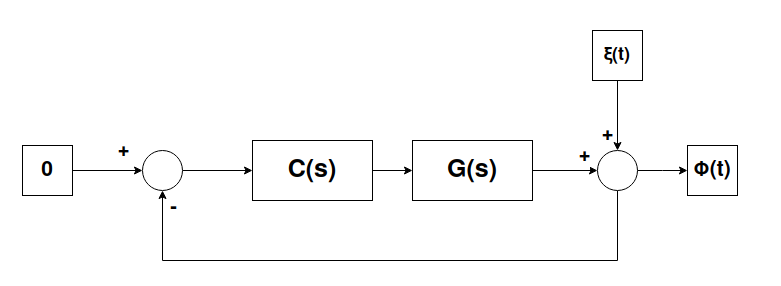

Using white noise as $\xi(t)$ we see two side bands on our resulting spectrum of the drive wave with this phase noise as expected from a frequency/phase modulation of this band filtered noise.

Using brown noise would result in a $\phi(t)$ that is equal to our spring mass filter on white noise since the $1/s$ shape of the brown noise would cancel with the $s$ factor on our transfer function. Though I made the simulation for the pink noise with this band pass transfer function in addition to the white noise.

By experimeting with the spectrum and our band pass filter we confirm that the noise that matters is still the noise that is close to the qubit resonance in the spectrum.

In [95]:
def band_pass(tlist, x_t, w0=1,Q=2, gain=1):
  #Y(s)=H(s)X(s)
  #system H(s) for a damped mass spring
  tf=TransferFunction([gain*w0/Q, 0],[1, w0/Q, w0**2])
  #y(t)
  _, y_t, _ = lsim(tf, U=x_t, T=tlist)
  return y_t


## White noise

In [124]:
#signal parameters
Det=0 # [GHz]
wd=wq+Det*2*np.pi # [rad.GHz]
tlist=np.linspace(0,500,int(500*3000/wq)+1) # ns
pure_drive=lambda t,phi: Ed*(np.sin((wd)*t+phi))
noise=band_pass(tlist, white_noise(len(tlist)))


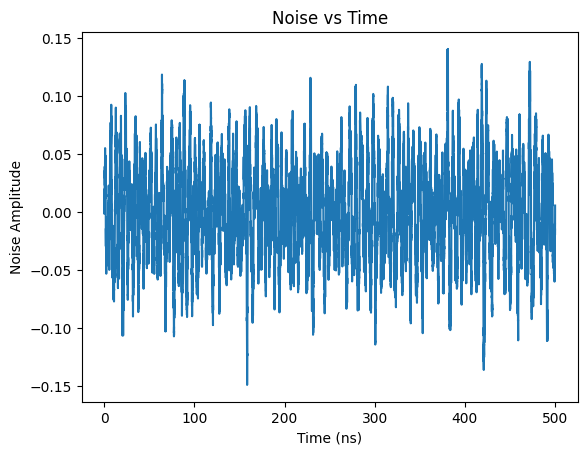

In [125]:
# prompt: plot the noise

# Assuming 'noise' is already defined from the previous code
plt.plot(tlist, noise)
plt.xlabel('Time (ns)')
plt.ylabel('Noise Amplitude')
plt.title('Noise vs Time')
plt.show()


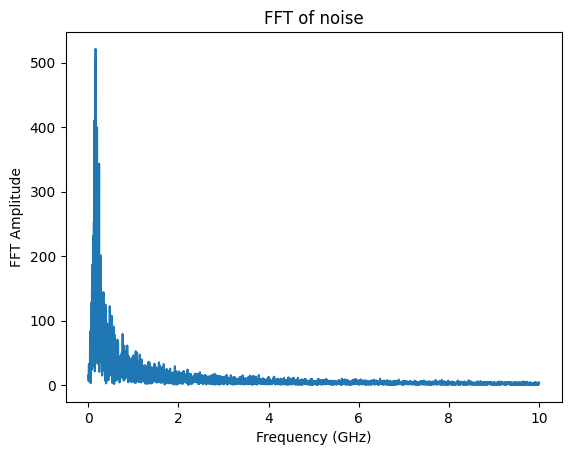

In [126]:
# prompt: plot the fft of drive_data with a proper freq axis

# Calculate the FFT
noise_fft = np.fft.fft(noise)

# Calculate the corresponding frequencies
freq = np.fft.fftfreq(len(tlist), d=tlist[1] - tlist[0])
middle=len(freq)//2
zoom=np.where((freq[:middle]>=0)&(freq[:middle]<=10))[0]
# Plot the FFT with proper frequency axis
plt.plot(freq[zoom], np.abs(noise_fft)[zoom])
plt.xlabel('Frequency (GHz)')
plt.ylabel('FFT Amplitude')
plt.title('FFT of noise')
plt.show()

Let's just generate signal with exagerated noise to be able to visualize it's effect more clearly.

In [127]:
drive_data=pure_drive(tlist,40*noise)

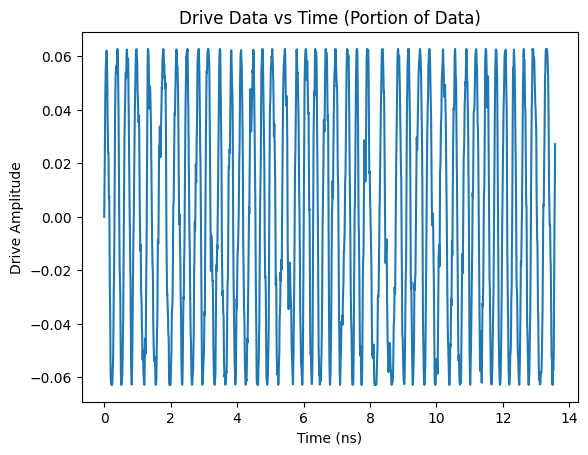

In [128]:

# Define the start and end indices for the portion you want to plot
start_index = 0
end_index = int(256/wq/500*len(tlist))  # Adjust as needed

# Create the plot for a specific range of 'tlist' and 'drive_data'
plt.plot(tlist[start_index:end_index], drive_data[start_index:end_index])
#plt.plot(tlist[start_index:end_index],0.05*np.random.normal(0,1, tlist.shape)[start_index:end_index])
plt.xlabel('Time (ns)')
plt.ylabel('Drive Amplitude')
plt.title('Drive Data vs Time (Portion of Data)')
plt.show()


In [139]:
drive_data=pure_drive(tlist,25*noise)

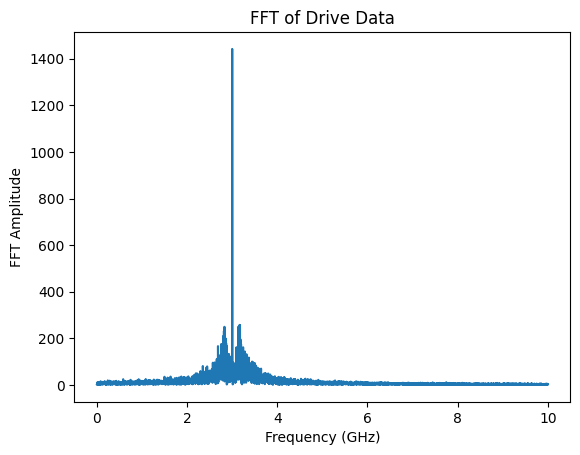

In [140]:
# prompt: plot the fft of drive_data with a proper freq axis

# Calculate the FFT
drive_fft = np.fft.fft(drive_data)

# Calculate the corresponding frequencies
freq = np.fft.fftfreq(len(tlist), d=tlist[1] - tlist[0])
middle=len(freq)//2
zoom=np.where((freq[:middle]>=0) & (freq[:middle]<=10))[0]
# Plot the FFT with proper frequency axis
plt.plot(freq[zoom], np.abs(drive_fft)[zoom])
plt.xlabel('Frequency (GHz)')
plt.ylabel('FFT Amplitude')
plt.title('FFT of Drive Data')
plt.show()

In [141]:
# initial state
psi0=qtp.basis(2,0)
t=np.linspace(0,500,1000) #ns
res=qtp.mesolve(H(wq,drive_data,tlist),psi0,t*wq,c_ops(T1, T2),e_ops=[sx, sy, sz],options=dict(nsteps=5000))

# rabi osc pi pulse
i=np.argmin(res.expect[2])
print("pi pulse:", t[i])


pi pulse: 86.0860860860861


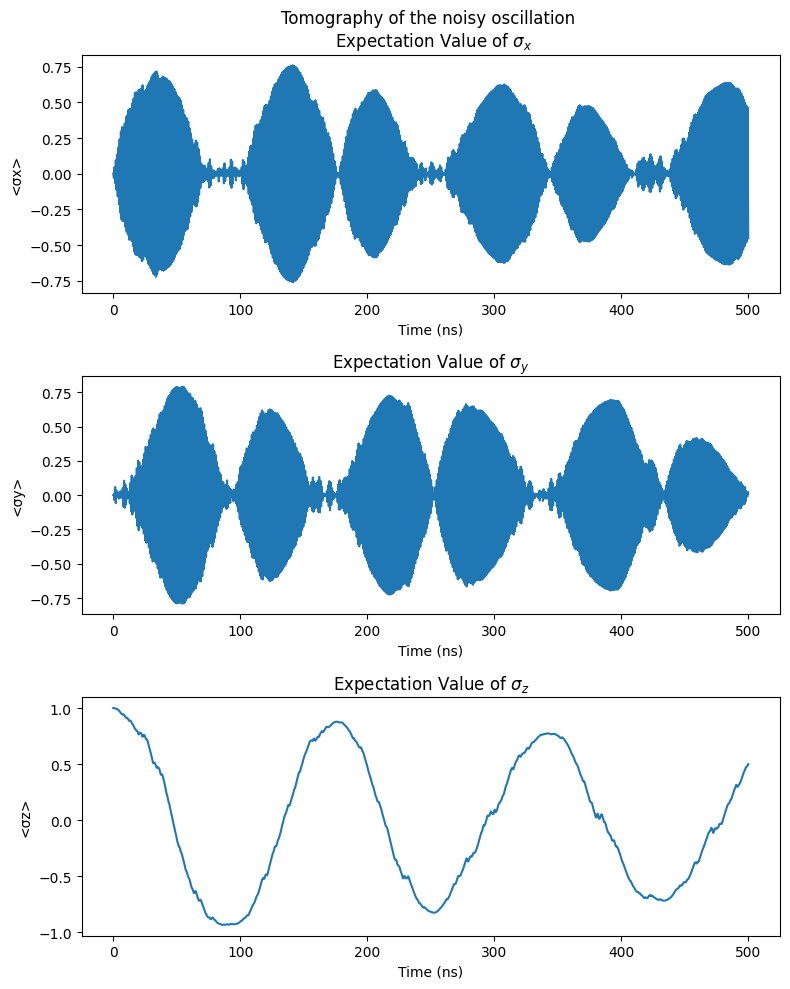

In [142]:
plot_tomography(res)

## Pink noise

In [111]:
#signal parameters
Det=0 # [GHz]
wd=wq+Det*2*np.pi # [rad.GHz]
tlist=np.linspace(0,500,int(500*3000/wq)+1) # ns
pure_drive=lambda t,phi: Ed*(np.sin((wd)*t+phi))
noise=band_pass(tlist, pink_noise(len(tlist)))


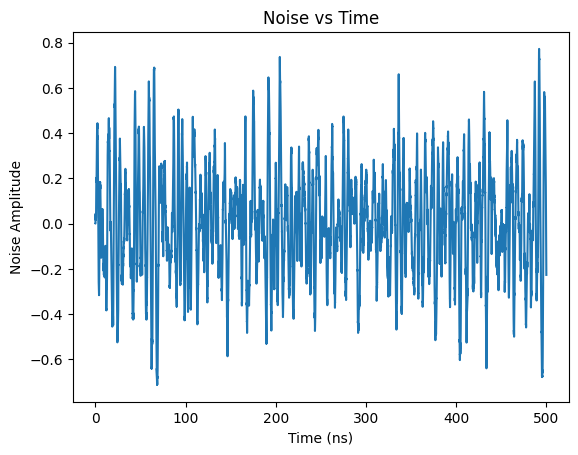

In [112]:
# prompt: plot the noise

# Assuming 'noise' is already defined from the previous code
plt.plot(tlist, noise)
plt.xlabel('Time (ns)')
plt.ylabel('Noise Amplitude')
plt.title('Noise vs Time')
plt.show()


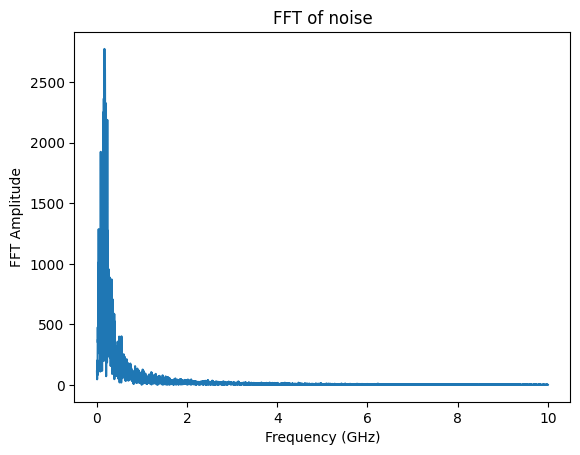

In [113]:
# prompt: plot the fft of drive_data with a proper freq axis

# Calculate the FFT
noise_fft = np.fft.fft(noise)

# Calculate the corresponding frequencies
freq = np.fft.fftfreq(len(tlist), d=tlist[1] - tlist[0])
middle=len(freq)//2
zoom=np.where((freq[:middle]>=0)&(freq[:middle]<=10))[0]
# Plot the FFT with proper frequency axis
plt.plot(freq[zoom], np.abs(noise_fft)[zoom])
plt.xlabel('Frequency (GHz)')
plt.ylabel('FFT Amplitude')
plt.title('FFT of noise')
plt.show()

Let's just generate signal with exagerated noise to be able to visualize it's effect more clearly.

In [114]:
drive_data=pure_drive(tlist,20*noise)

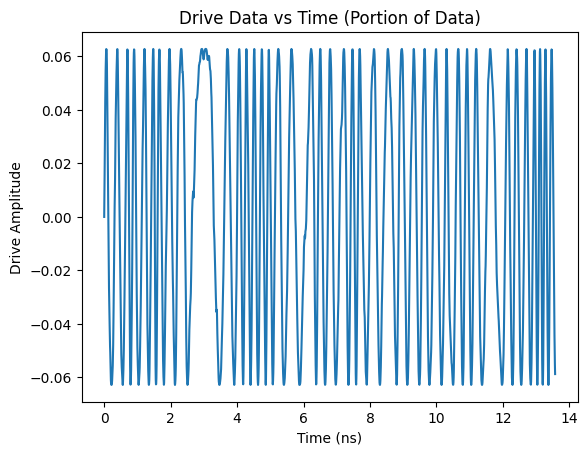

In [115]:

# Define the start and end indices for the portion you want to plot
start_index = 0
end_index = int(256/wq/500*len(tlist))  # Adjust as needed

# Create the plot for a specific range of 'tlist' and 'drive_data'
plt.plot(tlist[start_index:end_index], drive_data[start_index:end_index])
#plt.plot(tlist[start_index:end_index],0.05*np.random.normal(0,1, tlist.shape)[start_index:end_index])
plt.xlabel('Time (ns)')
plt.ylabel('Drive Amplitude')
plt.title('Drive Data vs Time (Portion of Data)')
plt.show()


In [120]:
drive_data=pure_drive(tlist,5*noise)

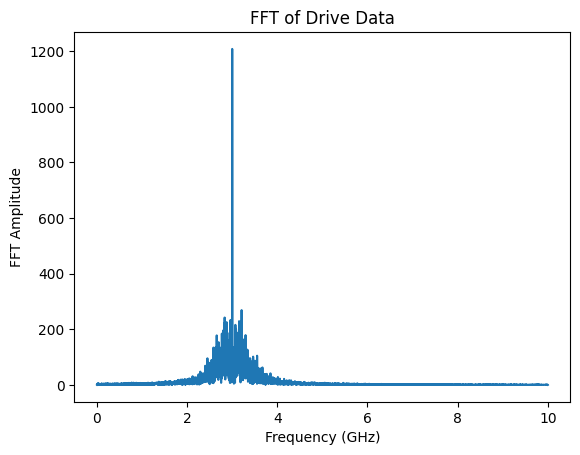

In [121]:
# prompt: plot the fft of drive_data with a proper freq axis

# Calculate the FFT
drive_fft = np.fft.fft(drive_data)

# Calculate the corresponding frequencies
freq = np.fft.fftfreq(len(tlist), d=tlist[1] - tlist[0])
middle=len(freq)//2
zoom=np.where((freq[:middle]>=0) & (freq[:middle]<=10))[0]
# Plot the FFT with proper frequency axis
plt.plot(freq[zoom], np.abs(drive_fft)[zoom])
plt.xlabel('Frequency (GHz)')
plt.ylabel('FFT Amplitude')
plt.title('FFT of Drive Data')
plt.show()

In [122]:
# initial state
psi0=qtp.basis(2,0)
t=np.linspace(0,500,1000) #ns
res=qtp.mesolve(H(wq,drive_data,tlist),psi0,t*wq,c_ops(T1, T2),e_ops=[sx, sy, sz],options=dict(nsteps=5000))

# rabi osc pi pulse
i=np.argmin(res.expect[2])
print("pi pulse:", t[i])


pi pulse: 130.63063063063063


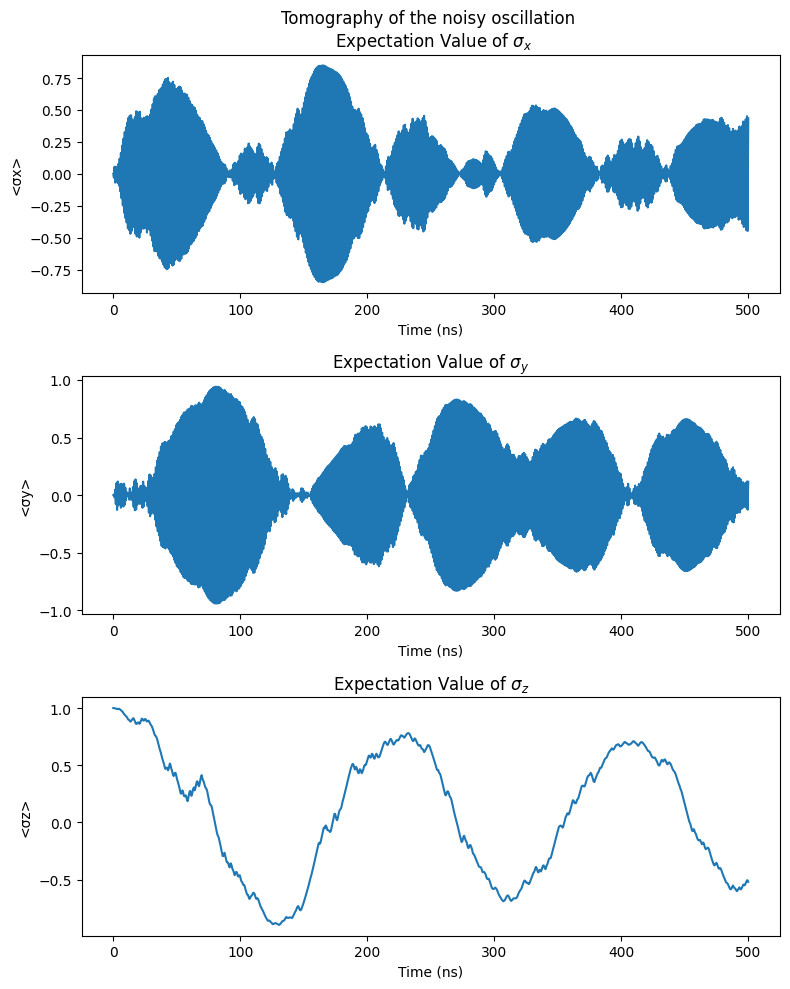

In [123]:
plot_tomography(res)